**Project Title**

Natural Disaster Prediction & Early Warning System

**Problem Satement**

Earthquakes are unpredictable natural disasters that cause severe loss of life and property worldwide. Despite continuous monitoring, the absence of reliable prediction and early warning systems limits disaster preparedness and risk management. There is a strong need to analyze historical seismic data to identify trends and patterns that can contribute toward building data-driven disaster prediction and early warning systems.

**Description**

This project focuses on analyzing earthquake data to identify trends and patterns that may assist in disaster prediction and early warning systems. It uses a dataset includes a record of the date, time, location, depth, magnitude, and source of every earthquake with a reported magnitude 5.5 or higher since 1965.

Context About Dataset

The National Earthquake Information Center (NEIC) determines the location and size of all significant earthquakes that occur worldwide and disseminates this information immediately to national and international agencies, scientists, critical facilities, and the general public. The NEIC compiles and provides to scientists and to the public an extensive seismic database that serves as a foundation for scientific research through the operation of modern digital national and global seismograph networks and cooperative international agreements. The NEIC is the national data center and archive for earthquake information.

This dataset serves as the foundation for our project’s analysis, enabling the application of AI/ML techniques for natural disaster prediction and early warning insights.

In [3]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [4]:
#load dataset
df=pd.read_csv("/content/dbEarthquake.csv")
#display first 5 rows
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01-02-1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01-04-1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01-05-1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01-08-1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01-09-1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [5]:
#display last 5 rows
df.tail()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,1.2,40.0,5.6,ML,...,18.0,42.47,0.120,NaN,0.1898,NN00570710,NN,NN,NN,Reviewed
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,2.0,33.0,5.5,ML,...,18.0,48.58,0.129,NaN,0.2187,NN00570744,NN,NN,NN,Reviewed
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,1.8,NaN,5.9,MWW,...,NaN,91.00,0.992,4.8,1.5200,US10007NAF,US,US,US,Reviewed
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,1.8,NaN,6.3,MWW,...,NaN,26.00,3.553,6.0,1.4300,US10007NL0,US,US,US,Reviewed
23411,12/30/2016,20:08:28,37.3973,141.4103,Earthquake,11.94,2.2,NaN,5.5,MB,...,428.0,97.00,0.681,4.5,0.9100,US10007NTD,US,US,US,Reviewed


In [6]:
df.head(10)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01-02-1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01-04-1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01-05-1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01-08-1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01-09-1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
5,01-10-1965,13:36:32,-13.405,166.629,Earthquake,35.0,NaN,NaN,6.7,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860922,ISCGEM,ISCGEM,ISCGEM,Automatic
6,01-12-1965,13:32:25,27.357,87.867,Earthquake,20.0,NaN,NaN,5.9,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861007,ISCGEM,ISCGEM,ISCGEM,Automatic
7,01/15/1965,23:17:42,-13.309,166.212,Earthquake,35.0,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861111,ISCGEM,ISCGEM,ISCGEM,Automatic
8,01/16/1965,11:32:37,-56.452,-27.043,Earthquake,95.0,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEMSUP861125,ISCGEMSUP,ISCGEM,ISCGEM,Automatic
9,01/17/1965,10:43:17,-24.563,178.487,Earthquake,565.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM861148,ISCGEM,ISCGEM,ISCGEM,Automatic


In [7]:
#explore and understand the data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [8]:
#Statistics of the dataset
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


In [9]:
#Find the missing value
df.isnull().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude,0
Magnitude Type,3


In [10]:
#Rows & Columns
df.shape

(23412, 21)

In [11]:
#columns
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='object')

**EDA(Exploratory Data Analysis)**

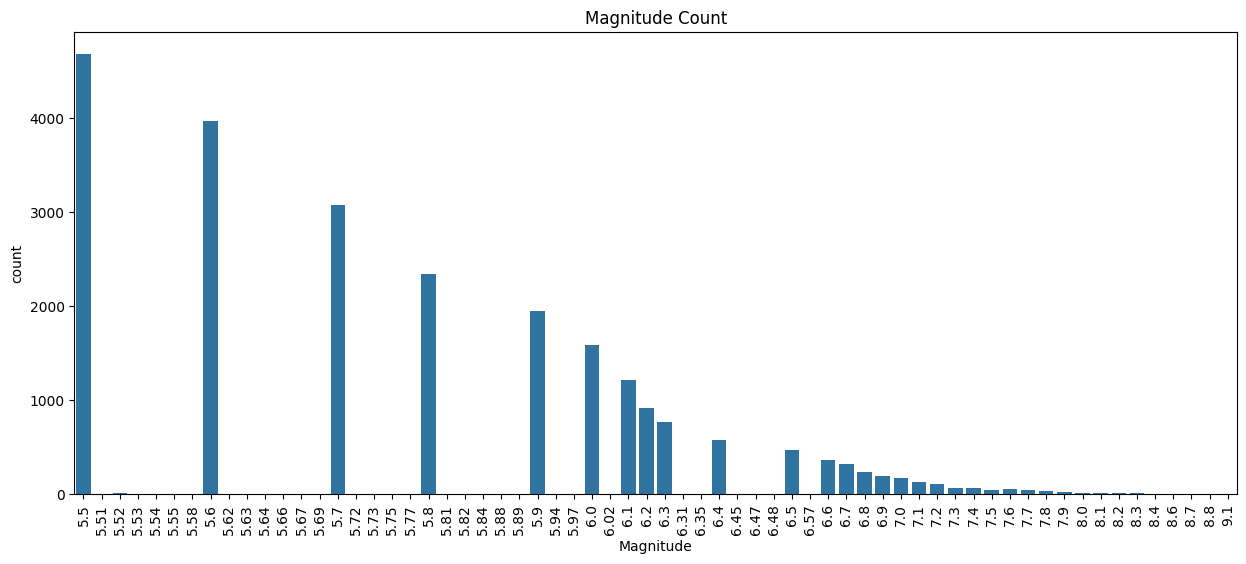

In [12]:
#Univariate Analysis
plt.figure(figsize=(15,6))#15 inches wide & 6 inches tall
plt.xticks(rotation=90)#rotate x-labels by 90 degrees
sns.countplot(x='Magnitude',data=df)
plt.title('Magnitude Count')
plt.show()

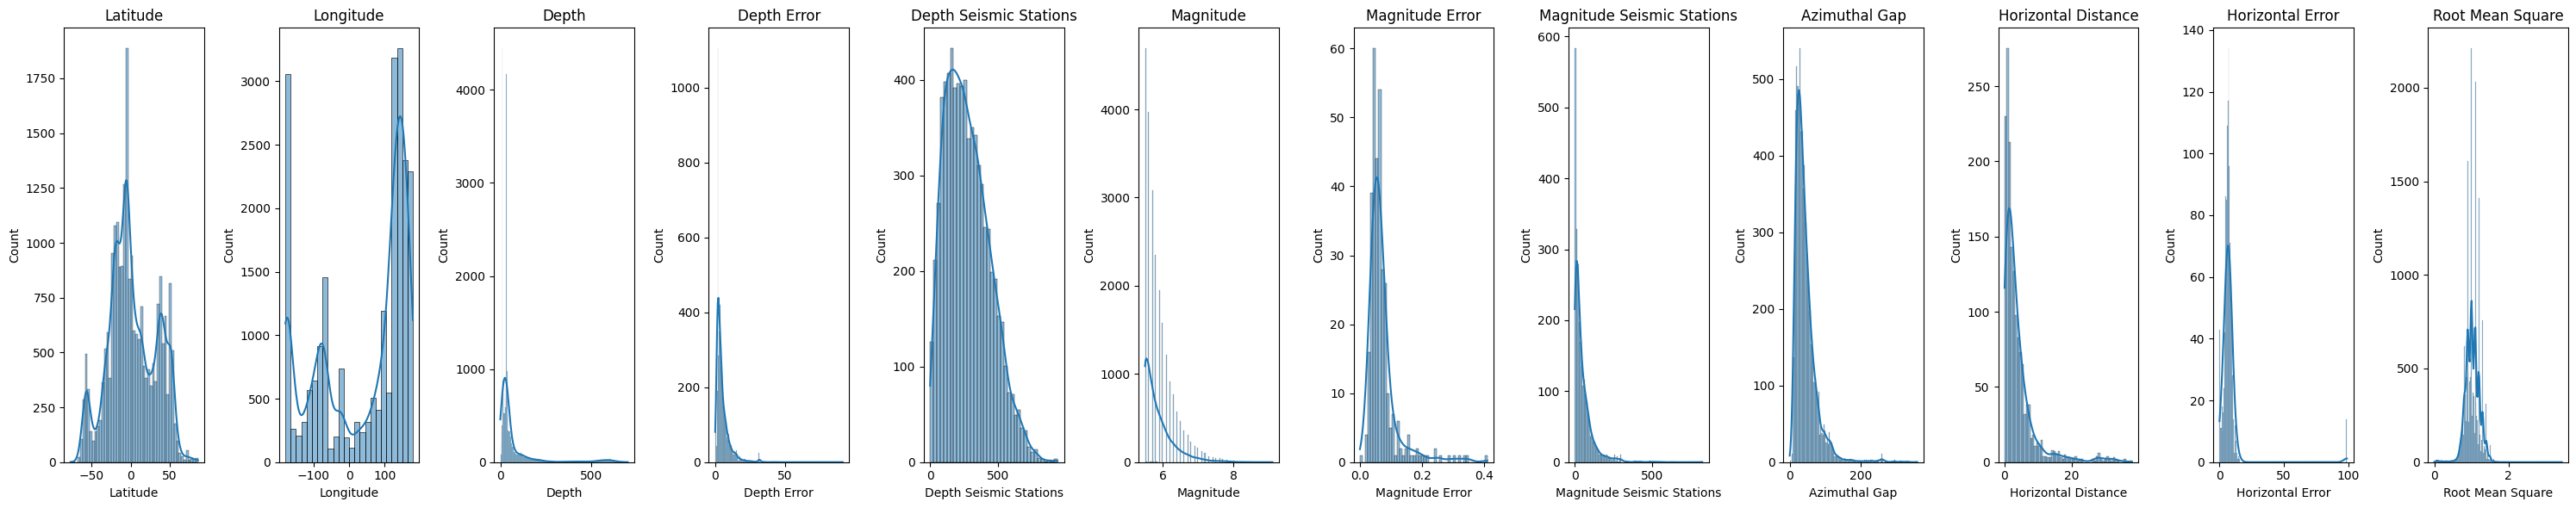

In [13]:
num_cols=['Latitude','Longitude','Depth','Depth Error','Depth Seismic Stations','Magnitude','Magnitude Error','Magnitude Seismic Stations','Azimuthal Gap','Horizontal Distance','Horizontal Error','Root Mean Square']
fig, axes=plt.subplots(1,12,figsize=(30,6))
for ax, col in zip(axes, num_cols):
  sns.histplot(df[col], kde=True, ax=ax)
  ax.set_title(col)
plt.tight_layout()
plt.show()

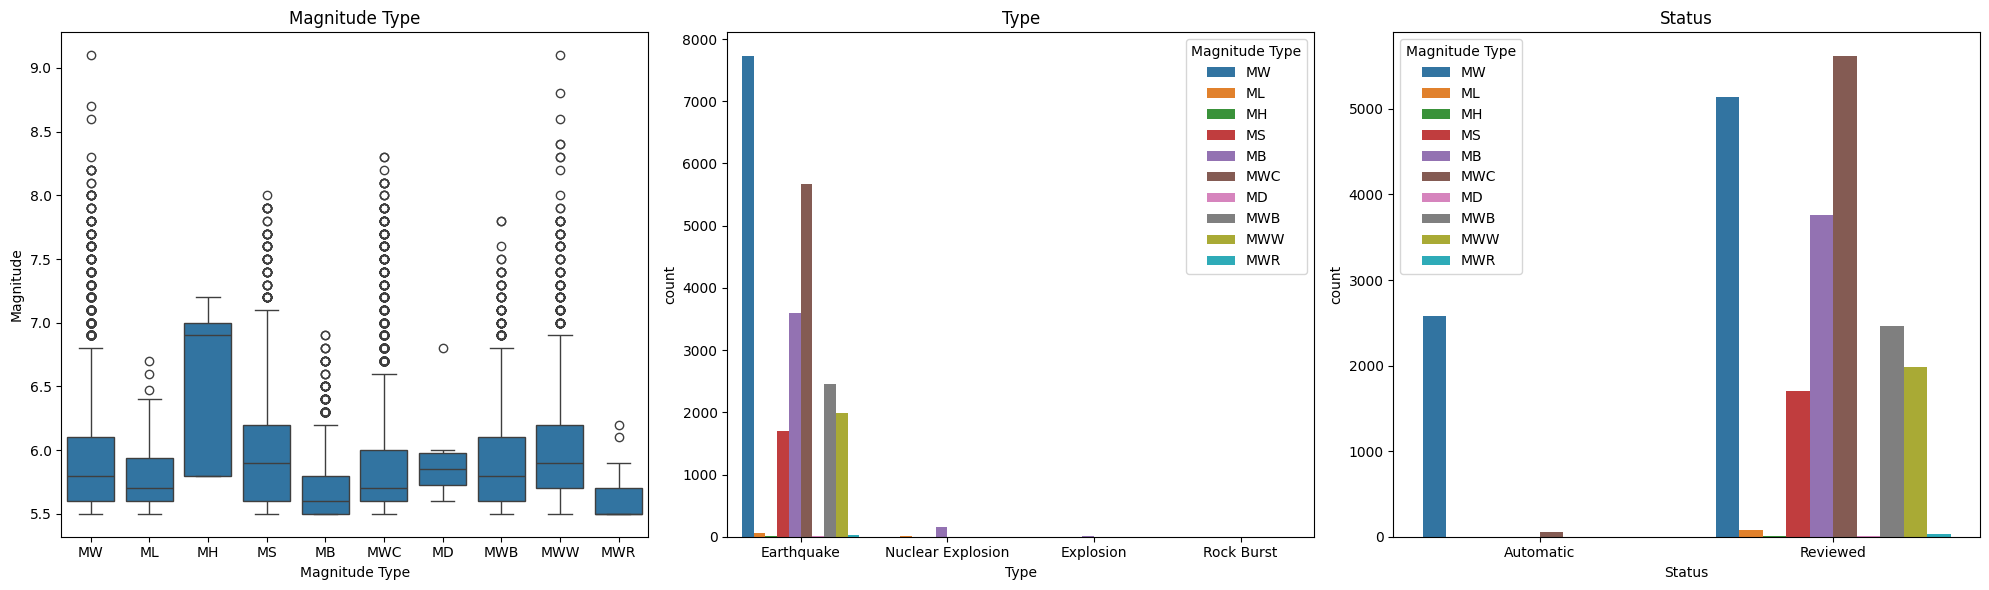

In [14]:
#Bivariate Analysis
fig, axes=plt.subplots(1,3,figsize=(20,6))
sns.boxplot(x='Magnitude Type', y='Magnitude', data=df, ax=axes[0]).set_title('Magnitude Type')
sns.countplot(x='Type', hue='Magnitude Type', data=df, ax=axes[1]).set_title('Type')
sns.countplot(x='Status', hue='Magnitude Type', data=df, ax=axes[2]).set_title('Status')
plt.tight_layout()
plt.show()

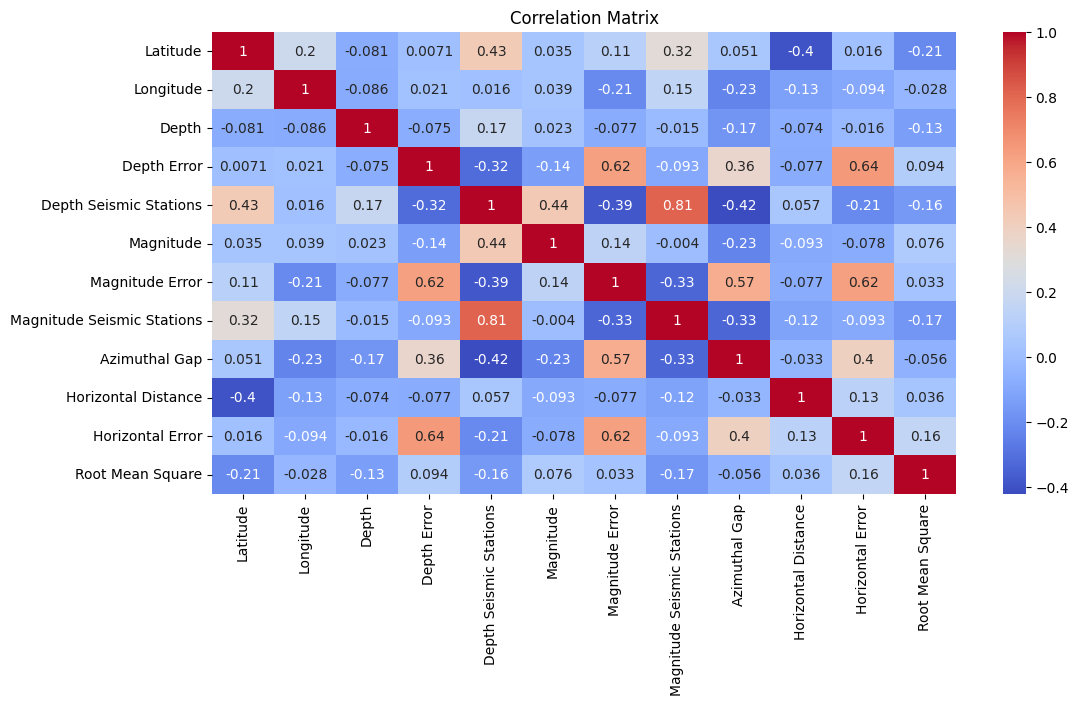

In [15]:
#Mutivariate Analysis
#correlation matrix for numerical features
plt.figure(figsize=(12,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#Pairplot for numerical features colored by Magnitude Type
sns.pairplot(df, vars=num_cols, hue='Magnitude Type')
plt.show()

In [17]:
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='object')

**Data Preprocessing or Data Preparation**

In [18]:
#Encode Categorical Variables
le=LabelEncoder()
categorical_cols=['Date','Time','ID','Source','Location Source','Magnitude Source','Magnitude Type','Status','Type']
for col in categorical_cols:
  df[col]=le.fit_transform(df[col])

In [19]:
#Feature & Target Selection(define features(X) & target(Y))
X = df.drop(['Magnitude Type'], axis=1)
y = df['Magnitude Type']

In [20]:
#Split data into training & test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.shape

(18729, 20)

In [22]:
X_test.shape

(4683, 20)

In [23]:
#Scale num features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [24]:
X_train.head(5)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
18765,11300,16254,0.436500,-0.804332,0,0.706910,NaN,2.377939,3.603613,NaN,NaN,-0.948056,NaN,NaN,-1.494100,20607,11,44,20,1
21035,10202,16167,-0.537035,-0.921513,0,-0.377018,NaN,1.218345,2.417173,NaN,NaN,0.067469,NaN,NaN,-0.115410,22865,11,44,20,1
18334,2866,11995,1.211696,-0.152755,0,-0.450923,NaN,1.463761,-0.430285,NaN,NaN,-0.273085,NaN,NaN,NaN,20178,11,5,20,1
16776,4290,11764,1.350361,0.841042,0,-0.339245,NaN,1.396272,-0.904861,NaN,NaN,1.107538,NaN,NaN,-1.175941,18625,11,44,20,1
9152,8073,14081,-0.584284,-1.687999,0,-0.344993,NaN,NaN,-0.430285,NaN,NaN,NaN,NaN,NaN,-0.645675,11077,11,44,10,1


In [25]:
# Impute missing values with the mean
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])


In [26]:
X_train.head(10)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
18765,11300,16254,0.436500,-0.804332,0,0.706910,-6.755720e-17,2.377939e+00,3.603613,-2.097543e-16,-3.434233e-17,-9.480562e-01,-1.910061e-17,-3.767459e-17,-1.494100e+00,20607,11,44,20,1
21035,10202,16167,-0.537035,-0.921513,0,-0.377018,-6.755720e-17,1.218345e+00,2.417173,-2.097543e-16,-3.434233e-17,6.746856e-02,-1.910061e-17,-3.767459e-17,-1.154100e-01,22865,11,44,20,1
18334,2866,11995,1.211696,-0.152755,0,-0.450923,-6.755720e-17,1.463761e+00,-0.430285,-2.097543e-16,-3.434233e-17,-2.730850e-01,-1.910061e-17,-3.767459e-17,-5.297974e-16,20178,11,5,20,1
16776,4290,11764,1.350361,0.841042,0,-0.339245,-6.755720e-17,1.396272e+00,-0.904861,-2.097543e-16,-3.434233e-17,1.107538e+00,-1.910061e-17,-3.767459e-17,-1.175941e+00,18625,11,44,20,1
9152,8073,14081,-0.584284,-1.687999,0,-0.344993,-6.755720e-17,-3.827544e-17,-0.430285,-2.097543e-16,-3.434233e-17,7.431821e-18,-1.910061e-17,-3.767459e-17,-6.456753e-01,11077,11,44,10,1
22095,2624,18352,-0.718880,-0.880279,0,-0.546834,-5.283789e-01,-3.827544e-17,-0.192997,-2.097543e-16,-3.434233e-17,1.095265e+00,-5.394628e-01,-3.767459e-17,9.451207e-01,4353,11,44,20,1
8407,2200,6102,-0.856809,-0.874759,0,-0.234958,-6.755720e-17,-3.827544e-17,0.518868,-2.097543e-16,-3.434233e-17,7.431821e-18,-1.910061e-17,-3.767459e-17,-6.456753e-01,10341,11,44,10,1
9016,4769,12852,0.210262,-0.621997,0,-0.491980,-6.755720e-17,-3.827544e-17,0.518868,-2.097543e-16,-3.434233e-17,7.431821e-18,-1.910061e-17,-3.767459e-17,4.148554e-01,10941,11,44,12,1
15521,7952,18603,-0.170411,0.851331,0,-0.491980,-6.755720e-17,-2.909686e-01,0.756156,-2.097543e-16,-3.434233e-17,7.431821e-18,-1.910061e-17,-3.767459e-17,1.157227e+00,17375,11,44,10,1
17840,3957,1471,-1.963243,0.861357,0,-0.491980,-6.755720e-17,-6.652292e-01,0.518868,-2.097543e-16,-3.434233e-17,-1.258186e-01,-1.910061e-17,-3.767459e-17,1.634466e+00,19684,11,44,20,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  int64  
 1   Time                        23412 non-null  int64  
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  int64  
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23412 non-null  int64  
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

### 🔍 Model Selection

In this project, we will evaluate **three different regression models** to predict earthquake-related parameters based on the dataset:

1. **Linear Regression**  
   A simple yet powerful baseline model that assumes a linear relationship between the input features and the target variable. It helps us establish a straightforward benchmark for performance.

2. **Random Forest Regressor**  
   An ensemble learning method that builds multiple decision trees and combines their predictions. It reduces overfitting and captures non-linear relationships, making it highly effective for complex datasets.

3. **Gradient Boosting Regressor**  
   Another ensemble technique that builds models sequentially, where each new model corrects the errors of the previous one. It usually provides strong predictive performance and is widely used in competitions and real-world applications.

➡️ By comparing these three models, we aim to understand which one provides the **best balance of accuracy and reliability** for earthquake prediction.


In [28]:
#Define Models
models = {
    "lr": LinearRegression(),
    "rf": RandomForestRegressor(random_state=42),
    "gb": GradientBoostingRegressor(random_state=42)
}

# Model Training & Evaluation

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Trains model, evaluates performance, stores results, and plots scatter plot."""
    # Train & predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    # Print performance
    print(f"\n🔹 {model_name} Performance:")
    print(f"   MSE  = {mse:.4f}")
    print(f"   MAE  = {mae:.4f}")
    print(f"   RMSE = {rmse:.4f}")
    print(f"   R²   = {r2:.4f}")
    # Save results for comparison
    results.append({
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })
    # Plot Predicted vs Actual
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name} - Predicted vs Actual")
    plt.show()
# Evaluate All Three Models
# Initialize an empty list to store evaluation results
results = []
evaluate_model(models["lr"], X_train, y_train, X_test, y_test, "Linear Regression")
evaluate_model(models["rf"], X_train, y_train, X_test, y_test, "Random Forest Regressor")
evaluate_model(models["gb"], X_train, y_train, X_test, y_test, "Gradient Boosting Regressor")

# Model Tuning & Optimization

In [ ]:
# Hyper Parameter Tuning For Random Forest Regressor
rf_param_grid = { 'n_estimators': [100, 200, 300],
                 'max_depth': [None, 10, 20, 30],
                  'min_samples_split': [2, 5, 10],
                  'min_samples_leaf': [1, 2, 4],
                  'max_features': ['auto', 'sqrt'] }
rf_random = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42), param_distributions=rf_param_grid, n_iter=20, cv=3, scoring='r2', n_jobs=-1, verbose=2, random_state=42)
# Fit to training data
rf_random.fit(X_train, y_train)
#Best prameters and score
print("Best Parameters:", rf_random.best_params_)
print("Best Score:", rf_random.best_score_)
#Evaluate Tuned Random Forest Regressor Model
evaluate_model(rf_random.best_estimator_, X_train, y_train, X_test, y_test, "Tuned Random Forest Regressor")


In [ ]:
# Hyper parameter for Gradient Boosting Regressor
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42), param_distributions=gb_param_grid, n_iter=10 , cv=2, scoring='r2', n_jobs=-1, verbose=1, random_state=42)
# Fit to training data
gb_random.fit(X_train, y_train)
# Best parameters and score
print("Best GB Parameters:", gb_random.best_params_)
print("Best GB Score:", gb_random.best_score_)

# Evaluate tuned Gradient Boosting Regressor model
evaluate_model(gb_random.best_estimator_, X_train, y_train, X_test, y_test, "Tuned Gradient Boosting Regressor")


Correlation Matrix

In [ ]:
#Create a copy of the dataset with encoded variables
df_corr=df.copy()
#Compute correlation matrix
corr_matrix = df_corr[['Date','Time','ID','Source','Location Source','Magnitude Source','Magnitude Type','Status','Type']].corr()
#Plot correlation matrix
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Numerical Features and Magnitude Type')
plt.show()
#Display correlation matrix
print(corr_matrix)

In [33]:
# After evaluating all models
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison Table:")
print(results_df)


📊 Model Comparison Table:
                               Model       MSE       MAE      RMSE        R²
0                  Linear Regression  4.639243  1.491972  2.153890  0.302835
1            Random Forest Regressor  0.449538  0.242300  0.670476  0.932445
2        Gradient Boosting Regressor  0.648733  0.498030  0.805440  0.902511
3      Tuned Random Forest Regressor  0.508330  0.332484  0.712972  0.923610
4  Tuned Gradient Boosting Regressor  0.477541  0.328353  0.691044  0.928237


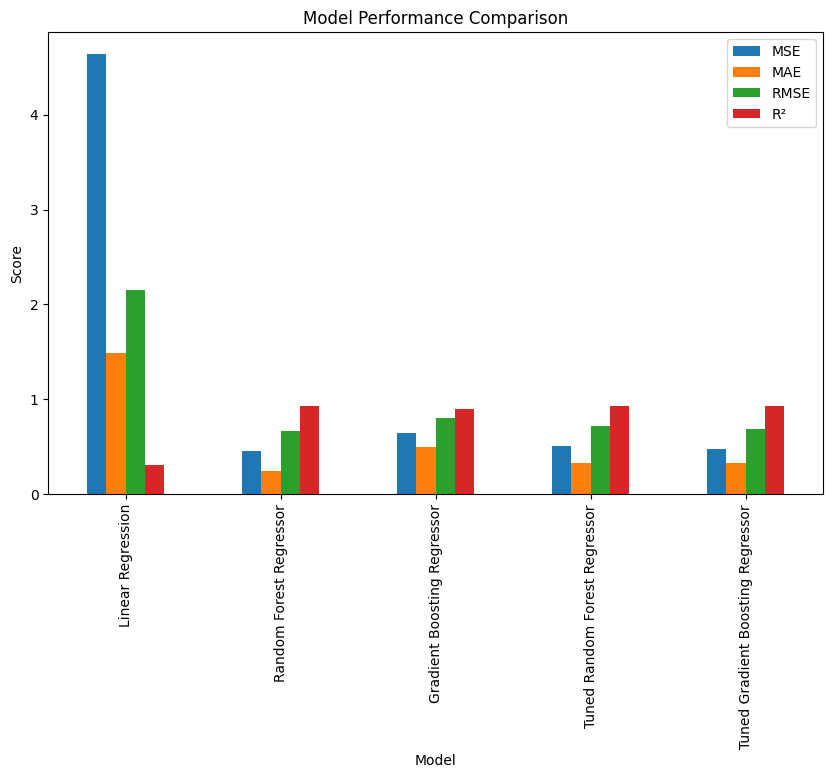

In [34]:
# Plot comparison chart
results_df.set_index("Model")[["MSE", "MAE", "RMSE", "R²"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.show()

# Final Model Testing & Saving

In [37]:
#Save the Linear Regression Model
joblib.dump(models["lr"], 'lr_model.pkl')
#Save the Random Forest Regressor Model
joblib.dump(rf_random.best_estimator_, 'rf_model.pkl')
#Save the Gradient Boosting Regressor Model
joblib.dump(gb_random.best_estimator_, 'gb_model.pkl')
#Save the scaler
joblib.dump(scaler, 'scaler.pkl')
#save the Encoded Categorical columns
cat_dict=categorical_cols
joblib.dump(cat_dict, 'cat_dict.pkl')
#save results
joblib.dump(results_df, 'results_df.pkl')

['results_df.pkl']